# Trabajo Unidad 2: Machine Learning
## Aprendizaje supervisado aplicado al dataset Titanic

**Asignatura:** Machine Learning  
**Universidad:** Universidad Mayor  
**Integrantes:** Javiera Retamal y Cesar Retamal  
**Docente:** Franco Andres Mansilla  
**Fecha:** septiembre de 2026

## Introducción

Este cuaderno continúa el pipeline reproducible construido en la Unidad 1 con el conjunto **Titanic - Machine Learning from Disaster**. El problema es de **clasificación binaria**: predecir si un pasajero sobrevivió (`Survived = 1`) o no sobrevivió (`Survived = 0`).

En esta etapa se entrenarán y compararán modelos supervisados con regularización, Random Forest, XGBoost y una red neuronal simple. Su desempeño se evaluará mediante Accuracy, Precision, Recall, F1-Score, ROC-AUC y KS. Luego se optimizarán hiperparámetros, se seleccionará un modelo final y se evaluará una sola vez sobre el test interno reservado.

El preprocesamiento permanecerá integrado a cada modelo mediante `Pipeline`, de modo que la imputación, codificación y estandarización se ajusten únicamente con los datos disponibles en cada entrenamiento.

## Objetivos

### Objetivo general
Evaluar la capacidad predictiva de distintos algoritmos supervisados para el problema Titanic y seleccionar un modelo final mediante métricas apropiadas para clasificación binaria.

### Objetivos específicos
1. Reutilizar de forma reproducible la preparación de datos de la Unidad 1.
2. Entrenar modelos penalizados, Random Forest, XGBoost y una red neuronal simple.
3. Comparar métricas de clasificación en entrenamiento y validación.
4. Optimizar hiperparámetros mediante validación cruzada estratificada.
5. Interpretar los resultados y seleccionar un modelo final.
6. Evaluar el modelo elegido sobre un test interno no utilizado durante el desarrollo.

## Organización del desarrollo por bloques

| Bloque | Contenido | Relación con la pauta |
|---|---|---|
| 1 | Base reproducible, datos, split y preprocesamiento | Continuidad de Unidad 1 |
| 2 | Modelos supervisados base | Punto 1 |
| 3 | Funciones y métricas de evaluación | Punto 2 |
| 4 | Comparación de resultados base | Puntos 2 y 4 |
| 5 | Optimización de hiperparámetros | Punto 3 |
| 6 | Interpretación y selección del modelo | Punto 4 |
| 7 | Evaluación única en test y predicción Kaggle | Punto 4 |
| 8 | GitHub, conclusión y bibliografía | Punto 5 y cierre |

# Bloque 1. Base reproducible y preparación de los datos

Este bloque recupera las decisiones de la Unidad 1. La partición se realiza antes de ajustar cualquier transformación dependiente de los datos. El test interno se reserva hasta que se haya seleccionado el modelo final.

In [1]:
from pathlib import Path
import platform
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import sklearn
from IPython.display import display
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer, OneHotEncoder, StandardScaler

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="colorblind")
pd.set_option("display.max_columns", 50)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print(f"Python: {platform.python_version()}")
print(f"pandas: {pd.__version__}")
print(f"scikit-learn: {sklearn.__version__}")

Python: 3.12.14
pandas: 3.0.5
scikit-learn: 1.9.0


In [2]:
# La detección permite ejecutar el cuaderno desde la raíz o desde notebooks/.
directorio_actual = Path.cwd().resolve()
if (directorio_actual / "data" / "train.csv").exists():
    PROJECT_DIR = directorio_actual
elif (directorio_actual.parent / "data" / "train.csv").exists():
    PROJECT_DIR = directorio_actual.parent
else:
    raise FileNotFoundError("No se encontró data/train.csv desde la ubicación actual.")

DATA_DIR = PROJECT_DIR / "data"
OUTPUT_DIR = PROJECT_DIR / "outputs"
OUTPUT_DIR.mkdir(exist_ok=True)

train_df = pd.read_csv(DATA_DIR / "train.csv")
kaggle_test_df = pd.read_csv(DATA_DIR / "test.csv")

assert train_df.shape == (891, 12), "La base train.csv no tiene la estructura esperada."
assert kaggle_test_df.shape == (418, 11), "La base test.csv no tiene la estructura esperada."
assert "Survived" in train_df.columns
assert "Survived" not in kaggle_test_df.columns

print(f"Ruta del proyecto: {PROJECT_DIR}")
print(f"Entrenamiento Kaggle: {train_df.shape[0]} filas y {train_df.shape[1]} columnas")
print(f"Test Kaggle: {kaggle_test_df.shape[0]} filas y {kaggle_test_df.shape[1]} columnas")
display(train_df.head())

Ruta del proyecto: C:\Users\cesar\Documents\Codex\Proyecto\trabajo_machine_learning_titanic
Entrenamiento Kaggle: 891 filas y 12 columnas
Test Kaggle: 418 filas y 11 columnas


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


### Ingeniería de características reutilizada

Se conservan las variables creadas en la Unidad 1: tratamiento del nombre (`Title`), tamaño familiar (`FamilySize`), indicador de viaje en solitario (`IsAlone`), disponibilidad de cabina (`HasCabin`) y cubierta (`Deck`). Los identificadores y textos de alta cardinalidad se excluyen del modelo base.

In [3]:
def crear_variables(dataframe):
    resultado = dataframe.copy()

    resultado["Title"] = (
        resultado["Name"]
        .str.extract(r",\s*([^.]*)\.", expand=False)
        .str.strip()
    )
    titulos_frecuentes = {"Mr", "Miss", "Mrs", "Master"}
    resultado["Title"] = resultado["Title"].where(
        resultado["Title"].isin(titulos_frecuentes),
        "Rare",
    )

    resultado["FamilySize"] = resultado["SibSp"] + resultado["Parch"] + 1
    resultado["IsAlone"] = (resultado["FamilySize"] == 1).astype(int)
    resultado["HasCabin"] = resultado["Cabin"].notna().astype(int)
    resultado["Deck"] = resultado["Cabin"].str[0].fillna("U")

    return resultado.drop(columns=["PassengerId", "Name", "Ticket", "Cabin"])

### Separación estratificada 70/15/15

La muestra de desarrollo de Kaggle se divide en entrenamiento, validación y test interno. La estratificación conserva aproximadamente la tasa de supervivencia en las tres muestras y `random_state=42` asegura reproducibilidad.

In [4]:
X_original = train_df.drop(columns="Survived")
y = train_df["Survived"].astype(int)

X_train_raw, X_temp_raw, y_train, y_temp = train_test_split(
    X_original,
    y,
    test_size=0.30,
    random_state=RANDOM_STATE,
    stratify=y,
)
X_valid_raw, X_test_raw, y_valid, y_test = train_test_split(
    X_temp_raw,
    y_temp,
    test_size=0.50,
    random_state=RANDOM_STATE,
    stratify=y_temp,
)

resumen_split = pd.DataFrame({
    "muestra": ["Entrenamiento", "Validación", "Test interno"],
    "observaciones": [len(y_train), len(y_valid), len(y_test)],
    "porcentaje": [len(y_train), len(y_valid), len(y_test)],
    "supervivencia_pct": [y_train.mean(), y_valid.mean(), y_test.mean()],
})
resumen_split["porcentaje"] = (resumen_split["porcentaje"] / len(train_df) * 100).round(2)
resumen_split["supervivencia_pct"] = (resumen_split["supervivencia_pct"] * 100).round(2)
display(resumen_split)

assert len(y_train) + len(y_valid) + len(y_test) == len(train_df)
assert set(X_train_raw.index).isdisjoint(X_valid_raw.index)
assert set(X_train_raw.index).isdisjoint(X_test_raw.index)
assert set(X_valid_raw.index).isdisjoint(X_test_raw.index)

,muestra,observaciones,porcentaje,supervivencia_pct
0,Entrenamiento,623,69.92,38.36
1,Validación,134,15.04,38.81
2,Test interno,134,15.04,38.06


In [5]:
X_train = crear_variables(X_train_raw)
X_valid = crear_variables(X_valid_raw)
X_test = crear_variables(X_test_raw)
X_kaggle = crear_variables(kaggle_test_df)

assert X_train.columns.tolist() == X_valid.columns.tolist() == X_test.columns.tolist()
assert X_train.columns.tolist() == X_kaggle.columns.tolist()

print(f"Variables predictoras después de ingeniería: {X_train.shape[1]}")
display(X_train.head())

Variables predictoras después de ingeniería: 12


,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,Title,FamilySize,IsAlone,HasCabin,Deck
748,1,male,19.0,1,0,53.1000,S,Mr,2,0,1,D
45,3,male,NaN,0,0,8.0500,S,Mr,1,1,0,U
28,3,female,NaN,0,0,7.8792,Q,Miss,1,1,0,U
633,1,male,NaN,0,0,0.0000,S,Mr,1,1,0,U
403,3,male,28.0,1,0,15.8500,S,Mr,2,0,0,U


### Preprocesamiento común para todos los modelos

Las variables numéricas se imputan por mediana y se estandarizan. `Fare` se transforma con `log1p` antes de escalarse. Las variables categóricas se imputan por moda y se codifican mediante one-hot encoding. El preprocesador todavía no se ajusta: cada modelo lo incorporará dentro de su propio `Pipeline`.

In [6]:
variables_numericas = ["Age", "SibSp", "Parch", "FamilySize"]
variable_tarifa = ["Fare"]
variables_categoricas = [
    "Pclass", "Sex", "Embarked", "Title", "IsAlone", "HasCabin", "Deck"
]

pipeline_numerico = Pipeline(steps=[
    ("imputacion_mediana", SimpleImputer(strategy="median")),
    ("escalamiento", StandardScaler()),
])

pipeline_tarifa = Pipeline(steps=[
    ("imputacion_mediana", SimpleImputer(strategy="median")),
    ("logaritmo", FunctionTransformer(np.log1p, feature_names_out="one-to-one")),
    ("escalamiento", StandardScaler()),
])

pipeline_categorico = Pipeline(steps=[
    ("imputacion_moda", SimpleImputer(strategy="most_frequent")),
    ("one_hot", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
])

preprocesamiento = ColumnTransformer(transformers=[
    ("numericas", pipeline_numerico, variables_numericas),
    ("tarifa", pipeline_tarifa, variable_tarifa),
    ("categoricas", pipeline_categorico, variables_categoricas),
])

columnas_esperadas = set(variables_numericas + variable_tarifa + variables_categoricas)
assert columnas_esperadas == set(X_train.columns)
print("Preprocesamiento definido correctamente y aún no ajustado.")

Preprocesamiento definido correctamente y aún no ajustado.


### Resultado del Bloque 1

La base quedó dividida en 623 observaciones de entrenamiento, 134 de validación y 134 de test interno. Las variables derivadas y el preprocesamiento son consistentes entre todas las muestras. El siguiente bloque incorporará los cuatro tipos de modelos solicitados, manteniendo el mismo tratamiento de datos para que la comparación sea justa.

# Bloque 2. Punto 1 - Entrenamiento de modelos supervisados

En este bloque se construyen seis configuraciones que representan las cuatro familias solicitadas: tres regresiones logísticas penalizadas, Random Forest, XGBoost y una red neuronal simple. Todos los modelos reciben las mismas variables y el mismo preprocesamiento, y se ajustan exclusivamente con la muestra de entrenamiento.

## 2.1. Algoritmos de penalización para clasificación binaria

Lasso, Ridge y Elastic Net se originan en modelos lineales. Como la variable objetivo de Titanic es binaria, las penalizaciones se aplican sobre una **regresión logística**:

- **L1 o Lasso:** puede llevar coeficientes a cero y actuar como selección de variables.
- **L2 o Ridge:** reduce la magnitud de los coeficientes sin eliminarlos normalmente.
- **Elastic Net:** combina L1 y L2 mediante `l1_ratio`.

Se utiliza el solver `saga` porque admite las tres penalizaciones. El parámetro `C` es el inverso de la fuerza de regularización: valores menores implican una penalización mayor.

In [7]:
from time import perf_counter

from sklearn.base import clone
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from xgboost import XGBClassifier
import xgboost

print(f"XGBoost: {xgboost.__version__}")

XGBoost: 3.4.1


## 2.2. Random Forest, XGBoost y red neuronal simple

- **Random Forest** combina árboles entrenados con muestras bootstrap y subconjuntos aleatorios de variables. El voto del conjunto reduce la varianza de un árbol individual.
- **XGBoost** construye árboles secuencialmente; cada nuevo árbol intenta corregir los errores acumulados. `learning_rate`, profundidad, número de árboles y muestreo controlan su complejidad.
- **Red neuronal simple** utiliza un perceptrón multicapa con dos capas ocultas. La activación ReLU permite relaciones no lineales y `early_stopping=True` detiene el entrenamiento cuando la mejora deja de ser significativa.

Las configuraciones de este bloque son puntos de partida razonables, no resultados finales. Sus hiperparámetros serán optimizados posteriormente.

In [8]:
estimadores_base = {
    "Logística L1 (Lasso)": LogisticRegression(
        penalty="l1", solver="saga", C=1.0, max_iter=5000,
        random_state=RANDOM_STATE,
    ),
    "Logística L2 (Ridge)": LogisticRegression(
        penalty="l2", solver="saga", C=1.0, max_iter=5000,
        random_state=RANDOM_STATE,
    ),
    "Logística Elastic Net": LogisticRegression(
        penalty="elasticnet", solver="saga", C=1.0, l1_ratio=0.5,
        max_iter=5000, random_state=RANDOM_STATE,
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=300, max_depth=None, min_samples_leaf=1,
        max_features="sqrt", n_jobs=-1, random_state=RANDOM_STATE,
    ),
    "XGBoost": XGBClassifier(
        n_estimators=250, max_depth=3, learning_rate=0.05,
        subsample=0.90, colsample_bytree=0.90,
        objective="binary:logistic", eval_metric="logloss",
        n_jobs=-1, random_state=RANDOM_STATE,
    ),
    "Red neuronal MLP": MLPClassifier(
        hidden_layer_sizes=(32, 16), activation="relu", solver="adam",
        alpha=0.001, learning_rate_init=0.001, max_iter=1000,
        early_stopping=True, validation_fraction=0.15,
        n_iter_no_change=30, random_state=RANDOM_STATE,
    ),
}

modelos_base = {
    nombre: Pipeline(steps=[
        ("preprocesamiento", clone(preprocesamiento)),
        ("clasificador", clone(estimador)),
    ])
    for nombre, estimador in estimadores_base.items()
}

assert len(modelos_base) == 6
display(pd.DataFrame({
    "modelo": list(modelos_base),
    "familia": [
        "Penalización L1", "Penalización L2", "Elastic Net",
        "Bagging de árboles", "Boosting de árboles", "Red neuronal",
    ],
}))

,modelo,familia
0,Logística L1 (Lasso),Penalización L1
1,Logística L2 (Ridge),Penalización L2
2,Logística Elastic Net,Elastic Net
3,Random Forest,Bagging de árboles
4,XGBoost,Boosting de árboles
5,Red neuronal MLP,Red neuronal


## 2.3. Ajuste inicial con la muestra de entrenamiento

Cada pipeline se ajusta con `X_train` y `y_train`. En esta etapa solo se comprueba que el entrenamiento termine correctamente y que cada modelo entregue predicciones binarias y probabilidades válidas para validación. Las métricas se calcularán juntas en el Bloque 3 para evitar repetir lógica.

In [9]:
modelos_ajustados = {}
predicciones_validacion = {}
probabilidades_validacion = {}
resumen_entrenamiento = []

for nombre, pipeline_modelo in modelos_base.items():
    inicio = perf_counter()
    pipeline_modelo.fit(X_train, y_train)
    segundos = perf_counter() - inicio

    prediccion = pipeline_modelo.predict(X_valid).astype(int)
    probabilidad = pipeline_modelo.predict_proba(X_valid)[:, 1]

    assert prediccion.shape == (len(y_valid),)
    assert probabilidad.shape == (len(y_valid),)
    assert set(np.unique(prediccion)).issubset({0, 1})
    assert np.isfinite(probabilidad).all()
    assert ((probabilidad >= 0) & (probabilidad <= 1)).all()

    modelos_ajustados[nombre] = pipeline_modelo
    predicciones_validacion[nombre] = prediccion
    probabilidades_validacion[nombre] = probabilidad
    resumen_entrenamiento.append({
        "modelo": nombre,
        "segundos_ajuste": segundos,
        "positivos_predichos_validación": int(prediccion.sum()),
        "variables_después_preproceso": len(
            pipeline_modelo.named_steps["preprocesamiento"].get_feature_names_out()
        ),
    })

resumen_entrenamiento = pd.DataFrame(resumen_entrenamiento)
resumen_entrenamiento["segundos_ajuste"] = resumen_entrenamiento["segundos_ajuste"].round(3)
display(resumen_entrenamiento)
print("Todos los modelos se ajustaron solamente con la muestra de entrenamiento.")

,modelo,segundos_ajuste,positivos_predichos_validación,variables_después_preproceso
0,Logística L1 (Lasso),0.034,54,31
1,Logística L2 (Ridge),0.041,53,31
2,Logística Elastic Net,0.070,54,31
3,Random Forest,0.248,44,31
4,XGBoost,0.182,44,31
5,Red neuronal MLP,0.071,45,31


Todos los modelos se ajustaron solamente con la muestra de entrenamiento.


### Resultado del Bloque 2

Los seis pipelines quedaron entrenados con la misma muestra y el mismo esquema de preprocesamiento. Todos producen una clase binaria y una probabilidad de supervivencia para cada observación de validación. Aún no se declara un modelo ganador: el Bloque 3 definirá y calculará métricas comparables tanto en entrenamiento como en validación.

# Bloque 3. Punto 2 — Métricas de desempeño

En este bloque se evalúan los seis modelos con un criterio uniforme. Las métricas se calculan en **entrenamiento** y **validación** para observar tanto el desempeño predictivo como posibles señales de sobreajuste. El conjunto de test interno continúa reservado y no se utiliza en esta etapa.

## 3.1 Métricas seleccionadas

- **Accuracy:** proporción total de predicciones correctas.
- **Precision:** proporción de supervivientes reales entre quienes fueron clasificados como supervivientes.
- **Recall:** proporción de supervivientes correctamente identificados.
- **F1-score:** media armónica entre precision y recall.
- **AUC-ROC:** capacidad del modelo para ordenar y separar ambas clases a través de todos los umbrales.
- **KS:** máxima separación entre las tasas acumuladas de verdaderos y falsos positivos; se calcula como $\max(TPR-FPR)$.

La variable objetivo `Survived` es binaria, por lo que **R² y RMSE no corresponden**: ambas son métricas propias de problemas de regresión.

In [10]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, confusion_matrix,
    ConfusionMatrixDisplay,
)

In [11]:
def calcular_ks(y_real, probabilidades):
    """Calcula el estadístico KS a partir de la curva ROC."""
    fpr, tpr, _ = roc_curve(y_real, probabilidades)
    return float(np.max(tpr - fpr))


def evaluar_modelo(nombre, modelo, X_evaluacion, y_evaluacion, muestra):
    """Devuelve las métricas de clasificación de un modelo y una muestra."""
    prediccion = modelo.predict(X_evaluacion)
    probabilidad = modelo.predict_proba(X_evaluacion)[:, 1]
    return {
        "modelo": nombre,
        "muestra": muestra,
        "Accuracy": accuracy_score(y_evaluacion, prediccion),
        "Precision": precision_score(y_evaluacion, prediccion, zero_division=0),
        "Recall": recall_score(y_evaluacion, prediccion, zero_division=0),
        "F1": f1_score(y_evaluacion, prediccion, zero_division=0),
        "AUC": roc_auc_score(y_evaluacion, probabilidad),
        "KS": calcular_ks(y_evaluacion, probabilidad),
    }

In [12]:
filas_metricas = []
for nombre, modelo in modelos_ajustados.items():
    filas_metricas.append(evaluar_modelo(nombre, modelo, X_train, y_train, "Entrenamiento"))
    filas_metricas.append(evaluar_modelo(nombre, modelo, X_valid, y_valid, "Validación"))

resultados_metricas = pd.DataFrame(filas_metricas)
orden_muestras = pd.CategoricalDtype(["Entrenamiento", "Validación"], ordered=True)
resultados_metricas["muestra"] = resultados_metricas["muestra"].astype(orden_muestras)
resultados_metricas = resultados_metricas.sort_values(["modelo", "muestra"]).reset_index(drop=True)
display(resultados_metricas.round(4))

,modelo,muestra,Accuracy,Precision,Recall,F1,AUC,KS
0,Logística Elastic Net,Entrenamiento,0.8395,0.8062,0.7657,0.7854,0.8827,0.6558
1,Logística Elastic Net,Validación,0.8806,0.8333,0.8654,0.8491,0.9235,0.7767
2,Logística L1 (Lasso),Entrenamiento,0.8411,0.8070,0.7699,0.7880,0.8828,0.6600
3,Logística L1 (Lasso),Validación,0.8806,0.8333,0.8654,0.8491,0.9245,0.7889
4,Logística L2 (Ridge),Entrenamiento,0.8331,0.7948,0.7615,0.7778,0.8828,0.6555
5,Logística L2 (Ridge),Validación,0.8881,0.8491,0.8654,0.8571,0.9240,0.7889
6,Random Forest,Entrenamiento,0.9807,0.9913,0.9582,0.9745,0.9977,0.9640
7,Random Forest,Validación,0.8358,0.8409,0.7115,0.7708,0.8540,0.6435
8,Red neuronal MLP,Entrenamiento,0.8507,0.8476,0.7448,0.7929,0.8857,0.6672
9,Red neuronal MLP,Validación,0.8582,0.8667,0.7500,0.8041,0.9041,0.7087


## 3.2 Desempeño de validación y brechas de generalización

Una brecha positiva y muy amplia entre entrenamiento y validación puede indicar sobreajuste. A continuación se comparan AUC y F1, dos métricas que resumen la capacidad de discriminación y el equilibrio entre precision y recall.

In [13]:
comparacion = resultados_metricas.pivot(index="modelo", columns="muestra", values=["AUC", "F1"])
tabla_brechas = pd.DataFrame({
    "AUC_entrenamiento": comparacion[("AUC", "Entrenamiento")],
    "AUC_validación": comparacion[("AUC", "Validación")],
    "brecha_AUC": comparacion[("AUC", "Entrenamiento")] - comparacion[("AUC", "Validación")],
    "F1_entrenamiento": comparacion[("F1", "Entrenamiento")],
    "F1_validación": comparacion[("F1", "Validación")],
    "brecha_F1": comparacion[("F1", "Entrenamiento")] - comparacion[("F1", "Validación")],
}).sort_values("AUC_validación", ascending=False)
display(tabla_brechas.round(4))

,AUC_entrenamiento,AUC_validación,brecha_AUC,F1_entrenamiento,F1_validación,brecha_F1
modelo,,,,,,
Logística L1 (Lasso),0.8828,0.9245,-0.0416,0.7880,0.8491,-0.0610
Logística L2 (Ridge),0.8828,0.9240,-0.0412,0.7778,0.8571,-0.0794
Logística Elastic Net,0.8827,0.9235,-0.0408,0.7854,0.8491,-0.0636
XGBoost,0.9565,0.9185,0.0380,0.8684,0.7917,0.0768
Red neuronal MLP,0.8857,0.9041,-0.0184,0.7929,0.8041,-0.0113
Random Forest,0.9977,0.8540,0.1437,0.9745,0.7708,0.2036


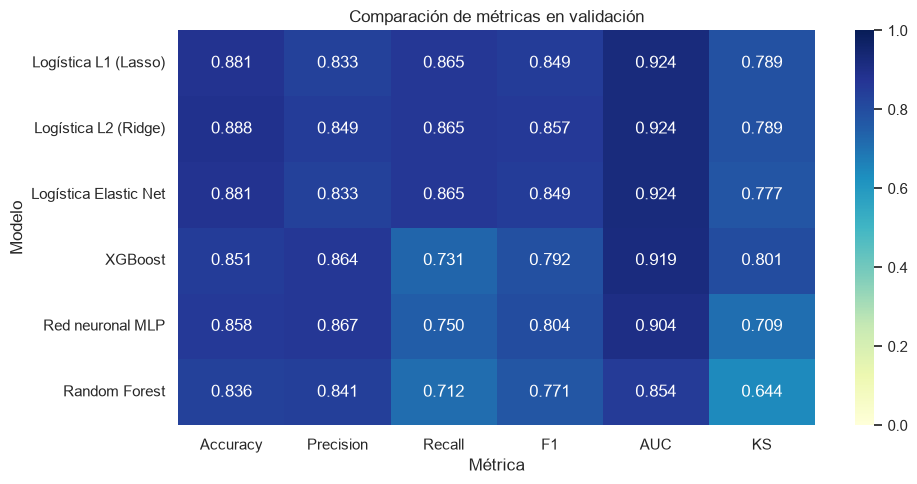

In [14]:
metricas_clasificacion = ["Accuracy", "Precision", "Recall", "F1", "AUC", "KS"]
metricas_validacion = (
    resultados_metricas[resultados_metricas["muestra"] == "Validación"]
    .set_index("modelo")[metricas_clasificacion]
    .sort_values("AUC", ascending=False)
)

plt.figure(figsize=(10, 5))
sns.heatmap(metricas_validacion, annot=True, fmt=".3f", cmap="YlGnBu", vmin=0, vmax=1)
plt.title("Comparación de métricas en validación")
plt.xlabel("Métrica")
plt.ylabel("Modelo")
plt.tight_layout()
plt.show()

## 3.3 Curvas ROC

La curva ROC muestra el intercambio entre la tasa de verdaderos positivos y la tasa de falsos positivos para todos los umbrales. Una curva más cercana a la esquina superior izquierda y un AUC mayor reflejan una mejor capacidad de separación.

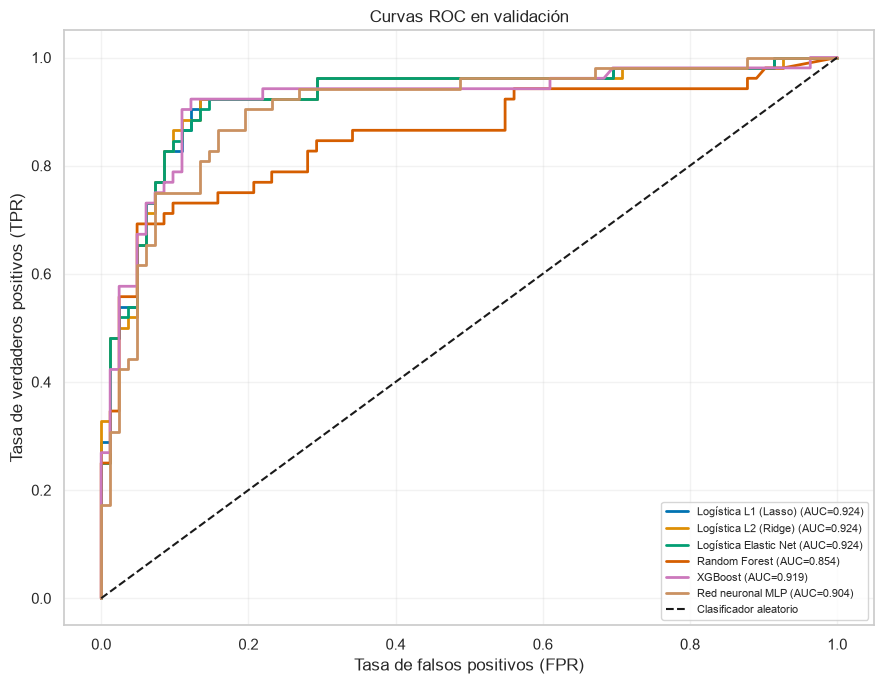

In [15]:
plt.figure(figsize=(9, 7))
for nombre, modelo in modelos_ajustados.items():
    probabilidad = modelo.predict_proba(X_valid)[:, 1]
    fpr, tpr, _ = roc_curve(y_valid, probabilidad)
    auc_modelo = roc_auc_score(y_valid, probabilidad)
    plt.plot(fpr, tpr, linewidth=2, label=f"{nombre} (AUC={auc_modelo:.3f})")

plt.plot([0, 1], [0, 1], "k--", label="Clasificador aleatorio")
plt.xlabel("Tasa de falsos positivos (FPR)")
plt.ylabel("Tasa de verdaderos positivos (TPR)")
plt.title("Curvas ROC en validación")
plt.legend(loc="lower right", fontsize=8)
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

## 3.4 Matrices de confusión

Las matrices permiten revisar los aciertos y errores de cada modelo con el umbral predeterminado de 0,5. La clase positiva corresponde a pasajeros que sobrevivieron.

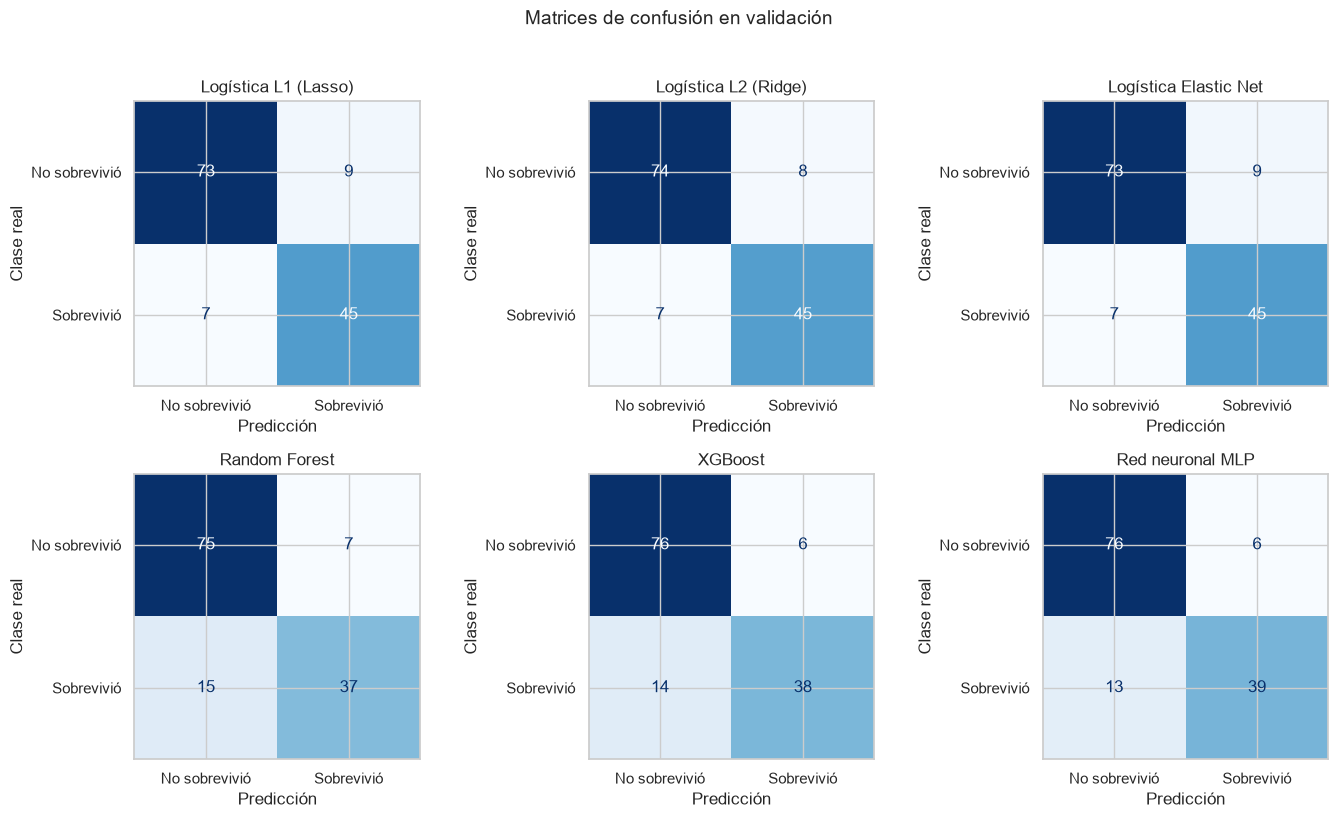

In [16]:
fig, ejes = plt.subplots(2, 3, figsize=(14, 8))
for eje, (nombre, modelo) in zip(ejes.ravel(), modelos_ajustados.items()):
    ConfusionMatrixDisplay.from_predictions(
        y_valid,
        modelo.predict(X_valid),
        labels=[0, 1],
        display_labels=["No sobrevivió", "Sobrevivió"],
        cmap="Blues",
        colorbar=False,
        ax=eje,
    )
    eje.set_title(nombre)
    eje.set_xlabel("Predicción")
    eje.set_ylabel("Clase real")

plt.suptitle("Matrices de confusión en validación", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## 3.5 Criterio de interpretación

La **accuracy** entrega una visión general, pero puede ocultar diferencias entre clases. La **precision** es relevante cuando se busca limitar falsos positivos; el **recall**, cuando interesa detectar la mayor cantidad posible de supervivientes; y **F1** equilibra ambos objetivos. La **AUC** será la métrica principal de comparación porque mide la capacidad de discriminación sin depender de un único umbral. F1, recall y KS se usarán como apoyo para evitar una elección basada en una sola cifra.

Estos resultados son una línea base comparable. La elección definitiva se realizará después de optimizar hiperparámetros y revisar las brechas de generalización; por ello todavía no se evalúa el test interno ni se declara un modelo final.

### Resultado del Bloque 3

Quedaron calculadas y visualizadas todas las métricas de clasificación solicitadas para entrenamiento y validación. El Bloque 4 profundizará en la comparación de resultados y el diagnóstico de sobreajuste antes de la optimización.

# Bloque 4. Comparación de resultados base

En este bloque se interpretan conjuntamente las métricas obtenidas. La comparación considera tres aspectos: **capacidad de discriminación**, **equilibrio de clasificación** y **generalización**. Se mantiene AUC como criterio principal, complementado por F1, KS y la brecha entre entrenamiento y validación.

## 4.1 Ranking en validación

El ranking principal se ordena por AUC. Además, se presentan las posiciones obtenidas en F1 y KS para comprobar que la conclusión no dependa de una sola métrica. El promedio de posiciones se utiliza únicamente como resumen descriptivo.

In [17]:
ranking_base = metricas_validacion.copy()
ranking_base["posición_AUC"] = ranking_base["AUC"].rank(ascending=False, method="min").astype(int)
ranking_base["posición_F1"] = ranking_base["F1"].rank(ascending=False, method="min").astype(int)
ranking_base["posición_KS"] = ranking_base["KS"].rank(ascending=False, method="min").astype(int)
ranking_base["posición_promedio"] = ranking_base[["posición_AUC", "posición_F1", "posición_KS"]].mean(axis=1)
ranking_base = ranking_base.sort_values(["posición_AUC", "posición_promedio"])
display(ranking_base.round(4))

,Accuracy,Precision,Recall,F1,AUC,KS,posición_AUC,posición_F1,posición_KS,posición_promedio
modelo,,,,,,,,,,
Logística L1 (Lasso),0.8806,0.8333,0.8654,0.8491,0.9245,0.7889,1,2,2,1.6667
Logística L2 (Ridge),0.8881,0.8491,0.8654,0.8571,0.9240,0.7889,2,1,2,1.6667
Logística Elastic Net,0.8806,0.8333,0.8654,0.8491,0.9235,0.7767,3,2,4,3.0000
XGBoost,0.8507,0.8636,0.7308,0.7917,0.9185,0.8011,4,5,1,3.3333
Red neuronal MLP,0.8582,0.8667,0.7500,0.8041,0.9041,0.7087,5,4,5,4.6667
Random Forest,0.8358,0.8409,0.7115,0.7708,0.8540,0.6435,6,6,6,6.0000


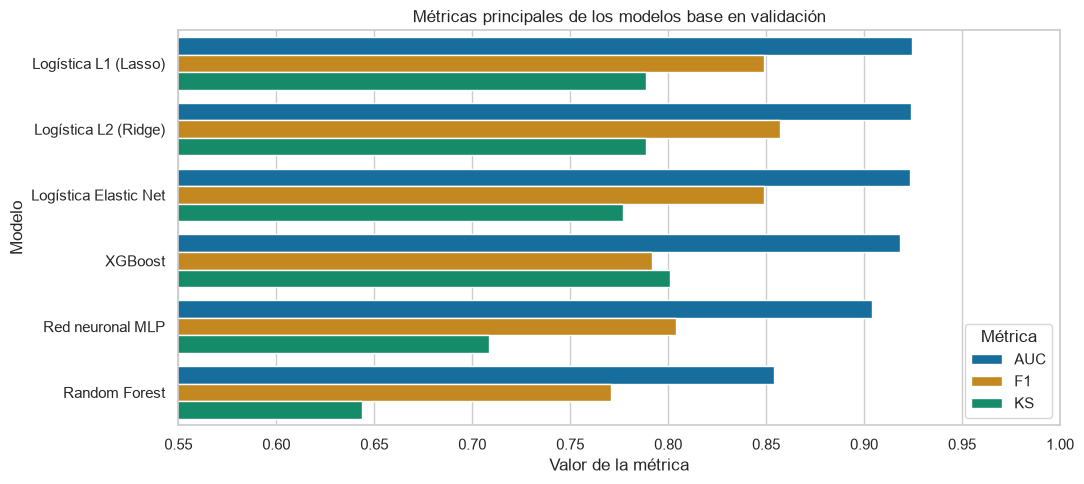

In [18]:
metricas_ranking = (
    ranking_base[["AUC", "F1", "KS"]]
    .reset_index()
    .melt(id_vars="modelo", var_name="métrica", value_name="valor")
)

plt.figure(figsize=(11, 5))
sns.barplot(data=metricas_ranking, x="valor", y="modelo", hue="métrica")
plt.xlim(0.55, 1.0)
plt.title("Métricas principales de los modelos base en validación")
plt.xlabel("Valor de la métrica")
plt.ylabel("Modelo")
plt.legend(title="Métrica", loc="lower right")
plt.tight_layout()
plt.show()

## 4.2 Diagnóstico de generalización

Se define la brecha como `métrica de entrenamiento − métrica de validación`. Una brecha positiva grande indica que el modelo aprende muy bien la muestra de entrenamiento, pero pierde desempeño al enfrentarse a datos no vistos. Una brecha negativa no implica por sí sola subajuste: puede aparecer cuando la partición de validación resulta algo más fácil que la de entrenamiento.

In [19]:
def clasificar_brecha_auc(brecha):
    if brecha > 0.10:
        return "Sobreajuste alto"
    if brecha > 0.03:
        return "Sobreajuste moderado"
    if brecha >= 0:
        return "Brecha baja"
    return "Sin evidencia de sobreajuste"

diagnostico_generalizacion = tabla_brechas.copy()
diagnostico_generalizacion["diagnóstico"] = diagnostico_generalizacion["brecha_AUC"].apply(clasificar_brecha_auc)
diagnostico_generalizacion = diagnostico_generalizacion.sort_values("brecha_AUC", ascending=False)
display(diagnostico_generalizacion.round(4))

,AUC_entrenamiento,AUC_validación,brecha_AUC,F1_entrenamiento,F1_validación,brecha_F1,diagnóstico
modelo,,,,,,,
Random Forest,0.9977,0.8540,0.1437,0.9745,0.7708,0.2036,Sobreajuste alto
XGBoost,0.9565,0.9185,0.0380,0.8684,0.7917,0.0768,Sobreajuste moderado
Red neuronal MLP,0.8857,0.9041,-0.0184,0.7929,0.8041,-0.0113,Sin evidencia de sobreajuste
Logística Elastic Net,0.8827,0.9235,-0.0408,0.7854,0.8491,-0.0636,Sin evidencia de sobreajuste
Logística L2 (Ridge),0.8828,0.9240,-0.0412,0.7778,0.8571,-0.0794,Sin evidencia de sobreajuste
Logística L1 (Lasso),0.8828,0.9245,-0.0416,0.7880,0.8491,-0.0610,Sin evidencia de sobreajuste


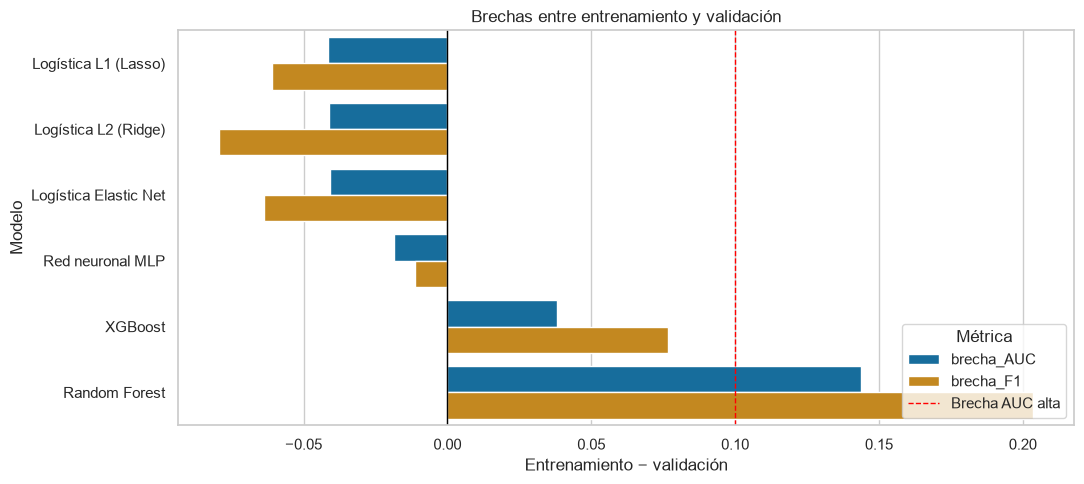

In [20]:
brechas_grafico = (
    tabla_brechas[["brecha_AUC", "brecha_F1"]]
    .sort_values("brecha_AUC")
    .reset_index()
    .melt(id_vars="modelo", var_name="métrica", value_name="brecha")
)

plt.figure(figsize=(11, 5))
sns.barplot(data=brechas_grafico, x="brecha", y="modelo", hue="métrica")
plt.axvline(0, color="black", linewidth=1)
plt.axvline(0.10, color="red", linestyle="--", linewidth=1, label="Brecha AUC alta")
plt.title("Brechas entre entrenamiento y validación")
plt.xlabel("Entrenamiento − validación")
plt.ylabel("Modelo")
plt.legend(title="Métrica", loc="lower right")
plt.tight_layout()
plt.show()

## 4.3 Interpretación de los resultados

1. **Regresión logística L1 (Lasso):** obtuvo el AUC de validación más alto (`0,9245`) y un F1 de `0,8491`. Su brecha AUC fue negativa y pequeña en términos prácticos, por lo que no hay evidencia de sobreajuste en esta partición.
2. **Regresión logística L2 (Ridge):** alcanzó la mayor accuracy (`0,8881`) y el mejor F1 (`0,8571`), con un AUC (`0,9240`) prácticamente igual al de L1. Es el resultado base más equilibrado.
3. **Elastic Net:** presentó un comportamiento casi idéntico a L1 y L2 (`AUC = 0,9235`), confirmando que los modelos lineales regularizados son sólidos para estas variables.
4. **XGBoost:** logró un AUC competitivo (`0,9185`) y el KS más alto (`0,8011`) en validación. Sin embargo, la diferencia con entrenamiento muestra sobreajuste moderado, por lo que existe margen para regularizarlo.
5. **Red neuronal MLP:** mostró resultados estables, pero quedó por debajo de las regresiones y XGBoost en AUC (`0,9041`). La cantidad de datos puede ser limitada para aprovechar plenamente un modelo más complejo.
6. **Random Forest:** alcanzó casi perfección en entrenamiento (`AUC = 0,9977`), pero descendió a `0,8540` en validación. La brecha de `0,1437` constituye la señal más clara de sobreajuste entre los modelos evaluados.

Que la validación supere al entrenamiento en los modelos logísticos y en MLP puede explicarse por variación muestral: la partición de validación contiene solo 134 observaciones y pudo resultar más fácil. Por este motivo, la siguiente etapa utilizará validación cruzada estratificada en vez de depender de una única partición.

## 4.4 Decisión para la etapa de optimización

Se conservarán como candidatos principales:

- **Logística L2**, por entregar el mejor equilibrio entre accuracy, F1, AUC y estabilidad.
- **Logística L1**, por liderar el ranking de AUC y ofrecer selección implícita de variables.
- **XGBoost**, por su alto AUC y el mejor KS, además de su potencial de mejora mediante regularización.
- **Random Forest**, no por su resultado base, sino para comprobar si limitar la complejidad reduce su sobreajuste.

Elastic Net y MLP permanecen en la comparación general, pero no se priorizan en la búsqueda debido a que no superaron a alternativas de su misma familia o nivel de complejidad. Esta preselección reduce el costo computacional y concentra la optimización en modelos con fortalezas distintas.

### Resultado del Bloque 4

Las regresiones regularizadas constituyen la línea base más sólida; XGBoost aparece como la alternativa no lineal más competitiva; y Random Forest requiere controlar su complejidad. En el Bloque 5 se aplicará optimización de hiperparámetros con validación cruzada estratificada, utilizando AUC como función objetivo.

# Bloque 5. Optimización de hiperparámetros

La optimización se realiza exclusivamente con la muestra de entrenamiento. Se utiliza **validación cruzada estratificada de 5 particiones**, que mantiene aproximadamente la proporción de supervivientes en cada fold y reduce la dependencia de una sola división de datos.

La función objetivo es **ROC-AUC**, elegida por su capacidad para evaluar la discriminación en todos los umbrales. Para las regresiones logísticas se aplica `GridSearchCV`, porque solo se explora el parámetro de regularización `C`. Para Random Forest y XGBoost se usa `RandomizedSearchCV`, más eficiente cuando existen múltiples hiperparámetros y muchas combinaciones posibles. El conjunto de validación externo al proceso se usa solamente para comparar los modelos resultantes; el test interno continúa reservado.

In [21]:
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV, StratifiedKFold

cv_estratificada = StratifiedKFold(
    n_splits=5, shuffle=True, random_state=RANDOM_STATE
)
print("Estrategia: 5-fold StratifiedKFold, métrica objetivo: ROC-AUC.")

Estrategia: 5-fold StratifiedKFold, métrica objetivo: ROC-AUC.


## 5.1 Espacios de búsqueda

Los rangos buscan controlar la complejidad sin hacer una búsqueda innecesariamente costosa. En regresión logística, valores pequeños de `C` implican mayor regularización. En los modelos de árboles se exploran profundidad, tamaño mínimo de hojas, muestreo de filas y columnas y penalizaciones.

In [22]:
grillas_logisticas = {
    "Logística L1 (Lasso)": {
        "clasificador__C": np.logspace(-3, 2, 11),
    },
    "Logística L2 (Ridge)": {
        "clasificador__C": np.logspace(-3, 2, 11),
    },
}

espacios_aleatorios = {
    "Random Forest": {
        "clasificador__n_estimators": [200, 300, 500, 700],
        "clasificador__max_depth": [4, 6, 8, 10, None],
        "clasificador__min_samples_split": [2, 5, 10, 20],
        "clasificador__min_samples_leaf": [1, 2, 4, 8],
        "clasificador__max_features": ["sqrt", "log2", 0.7],
        "clasificador__class_weight": [None, "balanced"],
    },
    "XGBoost": {
        "clasificador__n_estimators": [150, 250, 400, 600],
        "clasificador__max_depth": [2, 3, 4, 5],
        "clasificador__learning_rate": [0.01, 0.03, 0.05, 0.10],
        "clasificador__min_child_weight": [1, 3, 5],
        "clasificador__subsample": [0.70, 0.85, 1.00],
        "clasificador__colsample_bytree": [0.70, 0.85, 1.00],
        "clasificador__reg_alpha": [0.0, 0.01, 0.10, 1.0],
        "clasificador__reg_lambda": [0.5, 1.0, 3.0, 5.0],
    },
}

resumen_espacios = pd.DataFrame([
    {"modelo": nombre, "método": "GridSearchCV", "configuraciones": 11}
    for nombre in grillas_logisticas
] + [
    {"modelo": nombre, "método": "RandomizedSearchCV", "configuraciones": 16}
    for nombre in espacios_aleatorios
])
display(resumen_espacios)

,modelo,método,configuraciones
0,Logística L1 (Lasso),GridSearchCV,11
1,Logística L2 (Ridge),GridSearchCV,11
2,Random Forest,RandomizedSearchCV,16
3,XGBoost,RandomizedSearchCV,16


## 5.2 Ejecución de las búsquedas

Cada configuración se evalúa en los mismos cinco folds. El pipeline completo participa en la validación cruzada, por lo que la imputación, el escalamiento y la codificación se vuelven a ajustar dentro de cada fold, evitando fuga de información.

In [23]:
busquedas = {}
modelos_optimizados = {}
resumen_busquedas = []

for nombre, grilla in grillas_logisticas.items():
    buscador = GridSearchCV(
        estimator=clone(modelos_base[nombre]),
        param_grid=grilla,
        scoring="roc_auc",
        cv=cv_estratificada,
        n_jobs=-1,
        refit=True,
        return_train_score=True,
    )
    inicio = perf_counter()
    buscador.fit(X_train, y_train)
    segundos = perf_counter() - inicio
    indice = buscador.best_index_
    busquedas[nombre] = buscador
    modelos_optimizados[nombre] = buscador.best_estimator_
    resumen_busquedas.append({
        "modelo": nombre,
        "método": "GridSearchCV",
        "AUC_CV_entrenamiento": buscador.cv_results_["mean_train_score"][indice],
        "AUC_CV": buscador.best_score_,
        "desviación_AUC_CV": buscador.cv_results_["std_test_score"][indice],
        "brecha_CV": buscador.cv_results_["mean_train_score"][indice] - buscador.best_score_,
        "segundos": segundos,
    })

for nombre, espacio in espacios_aleatorios.items():
    estimador = clone(modelos_base[nombre])
    estimador.set_params(clasificador__n_jobs=1)
    buscador = RandomizedSearchCV(
        estimator=estimador,
        param_distributions=espacio,
        n_iter=16,
        scoring="roc_auc",
        cv=cv_estratificada,
        random_state=RANDOM_STATE,
        n_jobs=-1,
        refit=True,
        return_train_score=True,
    )
    inicio = perf_counter()
    buscador.fit(X_train, y_train)
    segundos = perf_counter() - inicio
    indice = buscador.best_index_
    busquedas[nombre] = buscador
    modelos_optimizados[nombre] = buscador.best_estimator_
    resumen_busquedas.append({
        "modelo": nombre,
        "método": "RandomizedSearchCV",
        "AUC_CV_entrenamiento": buscador.cv_results_["mean_train_score"][indice],
        "AUC_CV": buscador.best_score_,
        "desviación_AUC_CV": buscador.cv_results_["std_test_score"][indice],
        "brecha_CV": buscador.cv_results_["mean_train_score"][indice] - buscador.best_score_,
        "segundos": segundos,
    })

resumen_busquedas = pd.DataFrame(resumen_busquedas).sort_values("AUC_CV", ascending=False)
display(resumen_busquedas.round(4))

,modelo,método,AUC_CV_entrenamiento,AUC_CV,desviación_AUC_CV,brecha_CV,segundos
3,XGBoost,RandomizedSearchCV,0.9669,0.8808,0.0261,0.0861,1.0044
2,Random Forest,RandomizedSearchCV,0.9294,0.8754,0.0330,0.0540,2.3021
1,Logística L2 (Ridge),GridSearchCV,0.8809,0.8716,0.0311,0.0094,0.3685
0,Logística L1 (Lasso),GridSearchCV,0.8795,0.8705,0.0301,0.0090,3.0307


In [24]:
mejores_parametros = pd.DataFrame([
    {"modelo": nombre, "mejores_hiperparámetros": busqueda.best_params_}
    for nombre, busqueda in busquedas.items()
]).set_index("modelo")
pd.set_option("display.max_colwidth", None)
display(mejores_parametros)

,mejores_hiperparámetros
modelo,
Logística L1 (Lasso),{'clasificador__C': 0.31622776601683794}
Logística L2 (Ridge),{'clasificador__C': 0.1}
Random Forest,"{'clasificador__n_estimators': 200, 'clasificador__min_samples_split': 20, 'clasificador__min_samples_leaf': 2, 'clasificador__max_features': 'log2', 'clasificador__max_depth': None, 'clasificador__class_weight': None}"
XGBoost,"{'clasificador__subsample': 0.7, 'clasificador__reg_lambda': 1.0, 'clasificador__reg_alpha': 0.0, 'clasificador__n_estimators': 250, 'clasificador__min_child_weight': 3, 'clasificador__max_depth': 5, 'clasificador__learning_rate': 0.05, 'clasificador__colsample_bytree': 0.85}"


## 5.3 Comparación con los modelos base

Los mejores estimadores encontrados se aplican a la muestra de validación que no intervino en la búsqueda. La columna `cambio_AUC` representa la diferencia entre el AUC optimizado y el AUC del modelo base correspondiente.

In [25]:
filas_optimizadas = [
    evaluar_modelo(nombre, modelo, X_valid, y_valid, "Validación")
    for nombre, modelo in modelos_optimizados.items()
]
metricas_optimizadas = pd.DataFrame(filas_optimizadas).set_index("modelo")
auc_base_candidatos = metricas_validacion.loc[metricas_optimizadas.index, "AUC"]
comparacion_optimizacion = metricas_optimizadas.copy()
comparacion_optimizacion.insert(0, "AUC_base", auc_base_candidatos)
comparacion_optimizacion.insert(1, "cambio_AUC", comparacion_optimizacion["AUC"] - comparacion_optimizacion["AUC_base"])
comparacion_optimizacion = comparacion_optimizacion.sort_values("AUC", ascending=False)
display(comparacion_optimizacion.drop(columns="muestra").round(4))

,AUC_base,cambio_AUC,Accuracy,Precision,Recall,F1,AUC,KS
modelo,,,,,,,,
Logística L2 (Ridge),0.9240,-0.0070,0.8657,0.8269,0.8269,0.8269,0.9170,0.7819
Logística L1 (Lasso),0.9245,-0.0103,0.8582,0.8113,0.8269,0.8190,0.9142,0.7697
Random Forest,0.8540,0.0548,0.8209,0.8182,0.6923,0.7500,0.9088,0.7645
XGBoost,0.9185,-0.0122,0.8657,0.8864,0.7500,0.8125,0.9063,0.7261


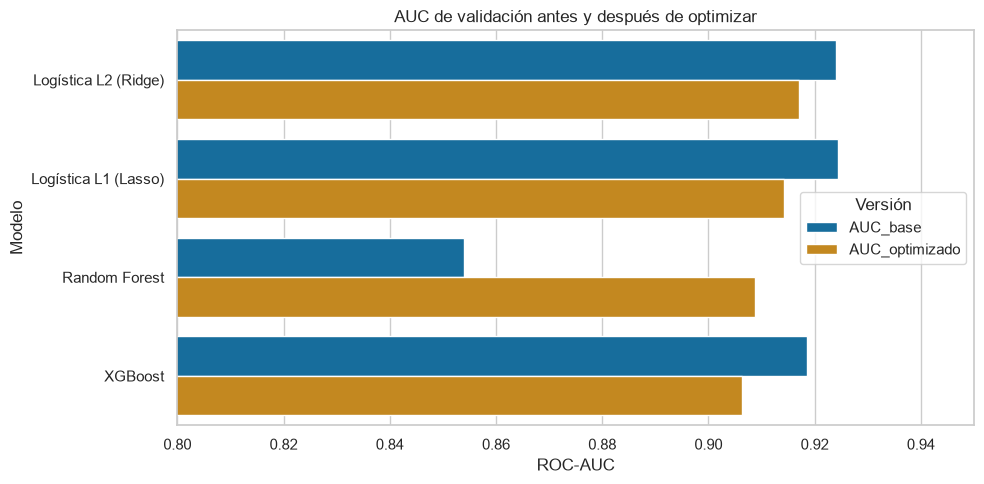

In [26]:
auc_comparativo = (
    comparacion_optimizacion[["AUC_base", "AUC"]]
    .rename(columns={"AUC": "AUC_optimizado"})
    .reset_index()
    .melt(id_vars="modelo", var_name="versión", value_name="AUC")
)

plt.figure(figsize=(10, 5))
sns.barplot(data=auc_comparativo, x="AUC", y="modelo", hue="versión")
plt.xlim(0.80, 0.95)
plt.title("AUC de validación antes y después de optimizar")
plt.xlabel("ROC-AUC")
plt.ylabel("Modelo")
plt.legend(title="Versión")
plt.tight_layout()
plt.show()

## 5.4 Robustez de los resultados

Para interpretar correctamente la optimización se presentan en conjunto el promedio AUC de validación cruzada, su desviación, la brecha interna de CV y el resultado sobre la validación externa. El promedio de cinco folds es una estimación más robusta que el resultado de una sola partición, aunque esta última sigue siendo útil como comprobación independiente.

In [27]:
tabla_decision_optimizacion = (
    resumen_busquedas.set_index("modelo")[[
        "AUC_CV", "desviación_AUC_CV", "brecha_CV"
    ]]
    .join(metricas_optimizadas[["Accuracy", "F1", "AUC", "KS"]])
    .rename(columns={"AUC": "AUC_validación_externa"})
    .sort_values("AUC_CV", ascending=False)
)
display(tabla_decision_optimizacion.round(4))

,AUC_CV,desviación_AUC_CV,brecha_CV,Accuracy,F1,AUC_validación_externa,KS
modelo,,,,,,,
XGBoost,0.8808,0.0261,0.0861,0.8657,0.8125,0.9063,0.7261
Random Forest,0.8754,0.0330,0.0540,0.8209,0.7500,0.9088,0.7645
Logística L2 (Ridge),0.8716,0.0311,0.0094,0.8657,0.8269,0.9170,0.7819
Logística L1 (Lasso),0.8705,0.0301,0.0090,0.8582,0.8190,0.9142,0.7697


## 5.5 Interpretación de la optimización

- **XGBoost** obtuvo el mayor AUC medio de validación cruzada (`0,8808`), pero conservó una brecha CV elevada (`0,0861`). En la validación externa alcanzó `0,9063`; además, su alta precision (`0,8864`) estuvo acompañada por un recall menor (`0,7500`).
- **Random Forest** elevó su AUC externo desde `0,8540` hasta `0,9088`, una mejora de `0,0548`. Los parámetros seleccionados aumentan el mínimo de observaciones necesario para dividir nodos y hojas, reduciendo la complejidad que provocaba el fuerte sobreajuste del modelo base.
- **Logística L2** obtuvo un AUC medio CV de `0,8716` y la menor brecha entre entrenamiento y CV entre los candidatos (`0,0094`). Aunque su AUC externo bajó levemente respecto del modelo base, quedó primero entre los modelos optimizados en esa muestra (`0,9170`) y mantuvo un buen equilibrio entre precision y recall.
- **Logística L1** mostró una estabilidad similar a L2, con AUC medio CV de `0,8705`, brecha de `0,0090` y AUC externo de `0,9142`.

Los cambios negativos frente al AUC base de algunos modelos no significan que la búsqueda haya fallado. El modelo base se observó sobre una sola partición que resultó especialmente favorable para las regresiones, mientras que la optimización eligió parámetros por el promedio de cinco folds del entrenamiento. Esta diferencia refuerza la necesidad de considerar rendimiento y estabilidad conjuntamente.

### Resultado del Bloque 5

La búsqueda identificó configuraciones reproducibles y redujo claramente el sobreajuste de Random Forest. XGBoost lideró el AUC promedio de validación cruzada, mientras Logística L2 ofreció la mejor combinación de estabilidad y desempeño externo. Ambos modelos pasan como candidatos centrales al Bloque 6, donde se justificará la selección del modelo final antes de abrir el test interno.

# Bloque 6. Interpretación y selección del modelo final

La decisión final se toma antes de observar el test interno. Se comparan los dos candidatos centrales con base en rendimiento promedio, estabilidad, validación externa e interpretabilidad. Esto evita seleccionar un modelo únicamente por la cifra más favorable de una sola evaluación.

## 6.1 Métrica de éxito

La métrica principal es **ROC-AUC** porque el objetivo consiste en distinguir pasajeros supervivientes de no supervivientes y esta medida evalúa la capacidad de ordenarlos correctamente a través de todos los umbrales posibles. Además, es menos dependiente del desbalance de clases y del umbral fijo que accuracy.

Como métricas secundarias se utilizan **F1**, para equilibrar precision y recall; **KS**, para medir la máxima separación entre clases; y la **brecha de generalización**, para controlar el sobreajuste. Accuracy se informa como referencia, pero no dirige por sí sola la elección.

In [28]:
candidatos_finales = ["Logística L2 (Ridge)", "XGBoost"]
comparacion_final = tabla_decision_optimizacion.loc[candidatos_finales, [
    "AUC_CV", "desviación_AUC_CV", "brecha_CV",
    "Accuracy", "F1", "AUC_validación_externa", "KS",
]].copy()
display(comparacion_final.round(4))

criterios_decision = pd.DataFrame({
    "criterio": [
        "Mayor AUC promedio en CV",
        "Menor brecha de generalización CV",
        "Mayor AUC en validación externa",
        "Mayor F1 en validación externa",
        "Interpretabilidad y parsimonia",
    ],
    "modelo favorecido": [
        "XGBoost",
        "Logística L2 (Ridge)",
        "Logística L2 (Ridge)",
        "Logística L2 (Ridge)",
        "Logística L2 (Ridge)",
    ],
    "fundamento": [
        "0,8808 frente a 0,8716",
        "0,0094 frente a 0,0861",
        "0,9170 frente a 0,9063",
        "0,8269 frente a 0,8125",
        "Modelo lineal regularizado y coeficientes inspeccionables",
    ],
})
display(criterios_decision)

,AUC_CV,desviación_AUC_CV,brecha_CV,Accuracy,F1,AUC_validación_externa,KS
modelo,,,,,,,
Logística L2 (Ridge),0.8716,0.0311,0.0094,0.8657,0.8269,0.9170,0.7819
XGBoost,0.8808,0.0261,0.0861,0.8657,0.8125,0.9063,0.7261


,criterio,modelo favorecido,fundamento
0,Mayor AUC promedio en CV,XGBoost,"0,8808 frente a 0,8716"
1,Menor brecha de generalización CV,Logística L2 (Ridge),"0,0094 frente a 0,0861"
2,Mayor AUC en validación externa,Logística L2 (Ridge),"0,9170 frente a 0,9063"
3,Mayor F1 en validación externa,Logística L2 (Ridge),"0,8269 frente a 0,8125"
4,Interpretabilidad y parsimonia,Logística L2 (Ridge),Modelo lineal regularizado y coeficientes inspeccionables


## 6.2 Selección del modelo

Se selecciona **Regresión Logística L2 (Ridge)** como modelo final. Aunque XGBoost supera a Ridge en AUC promedio de validación cruzada por `0,0092`, esa diferencia es pequeña frente a la variabilidad observada entre folds. Ridge presenta una brecha CV mucho menor (`0,0094` frente a `0,0861`), obtiene mejores AUC y F1 en la validación externa y permite una interpretación más directa.

La regularización L2 reduce la sensibilidad a variables correlacionadas y limita coeficientes extremos sin eliminar predictores. Esta combinación de estabilidad, desempeño y simplicidad resulta preferible para un conjunto relativamente pequeño como Titanic.

In [29]:
NOMBRE_MODELO_FINAL = "Logística L2 (Ridge)"
UMBRAL_FINAL = 0.50
modelo_final = modelos_optimizados[NOMBRE_MODELO_FINAL]
hiperparametros_finales = busquedas[NOMBRE_MODELO_FINAL].best_params_

assert NOMBRE_MODELO_FINAL in modelos_optimizados
assert modelo_final is busquedas[NOMBRE_MODELO_FINAL].best_estimator_
print(f"Modelo seleccionado: {NOMBRE_MODELO_FINAL}")
print(f"Hiperparámetros: {hiperparametros_finales}")
print(f"Umbral de clasificación fijado: {UMBRAL_FINAL:.2f}")

Modelo seleccionado: Logística L2 (Ridge)
Hiperparámetros: {'clasificador__C': np.float64(0.1)}
Umbral de clasificación fijado: 0.50


## 6.3 Interpretabilidad del modelo seleccionado

Se utiliza importancia por permutación sobre la validación para cuantificar cuánto disminuye el AUC cuando se desordena cada variable original. Esta técnica permite interpretar el pipeline completo y comparar las variables antes de su codificación. Una importancia cercana a cero indica que, en esta muestra y en presencia de las demás variables, el predictor aporta poca información adicional.

,variable,importancia_media_AUC,desviación
0,Sex,0.0548,0.0173
1,Title,0.0523,0.0151
2,SibSp,0.0193,0.0094
3,Fare,0.0125,0.0112
4,Pclass,0.0119,0.0070
5,FamilySize,0.0118,0.0075
6,Parch,0.0023,0.0019
7,HasCabin,0.0004,0.0069
8,Deck,-0.0007,0.0047
9,Age,-0.0020,0.0095


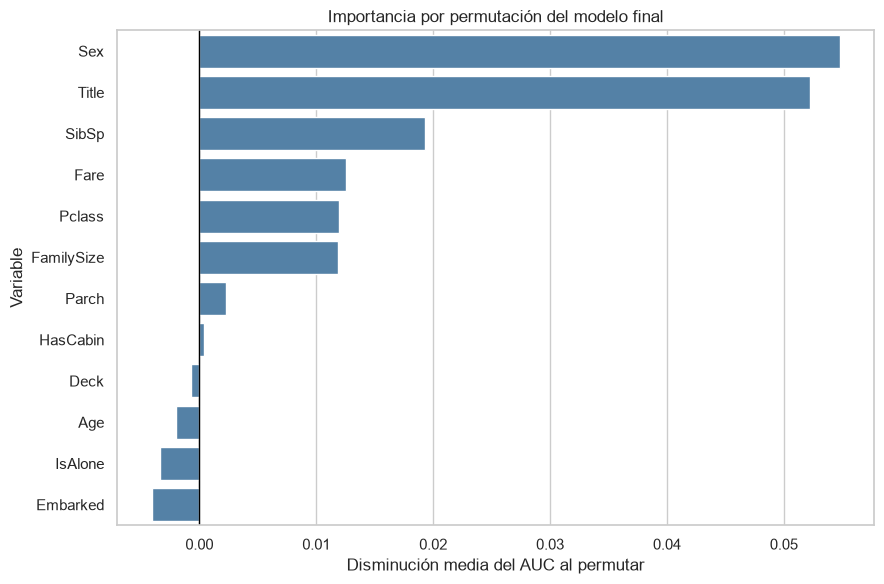

In [30]:
from sklearn.inspection import permutation_importance

permutacion = permutation_importance(
    modelo_final,
    X_valid,
    y_valid,
    scoring="roc_auc",
    n_repeats=30,
    random_state=RANDOM_STATE,
    n_jobs=1,
)
importancia_variables = (
    pd.DataFrame({
        "variable": X_valid.columns,
        "importancia_media_AUC": permutacion.importances_mean,
        "desviación": permutacion.importances_std,
    })
    .sort_values("importancia_media_AUC", ascending=False)
    .reset_index(drop=True)
)
display(importancia_variables.round(4))

plt.figure(figsize=(9, 6))
sns.barplot(data=importancia_variables, x="importancia_media_AUC", y="variable", color="steelblue")
plt.axvline(0, color="black", linewidth=1)
plt.title("Importancia por permutación del modelo final")
plt.xlabel("Disminución media del AUC al permutar")
plt.ylabel("Variable")
plt.tight_layout()
plt.show()

## 6.4 Dirección de las asociaciones

Los coeficientes permiten observar si cada variable transformada se asocia con una mayor o menor probabilidad estimada de supervivencia. Un coeficiente positivo aumenta el logaritmo de las probabilidades relativas (*log-odds*) y uno negativo lo reduce, manteniendo constantes los demás predictores. Estas asociaciones son predictivas y **no demuestran causalidad**.

,variable_transformada,coeficiente,magnitud_absoluta,odds_ratio
15,categoricas__Title_Mr,-0.9103,0.9103,0.4024
8,categoricas__Sex_female,0.6376,0.6376,1.8919
9,categoricas__Sex_male,-0.6328,0.6328,0.5311
16,categoricas__Title_Mrs,0.4469,0.4469,1.5634
0,numericas__Age,-0.4114,0.4114,0.6627
4,tarifa__Fare,0.3681,0.3681,1.4450
13,categoricas__Title_Master,0.3623,0.3623,1.4366
7,categoricas__Pclass_3,-0.3486,0.3486,0.7056
21,categoricas__HasCabin_1,0.3200,0.3200,1.3771
30,categoricas__Deck_U,-0.3152,0.3152,0.7296


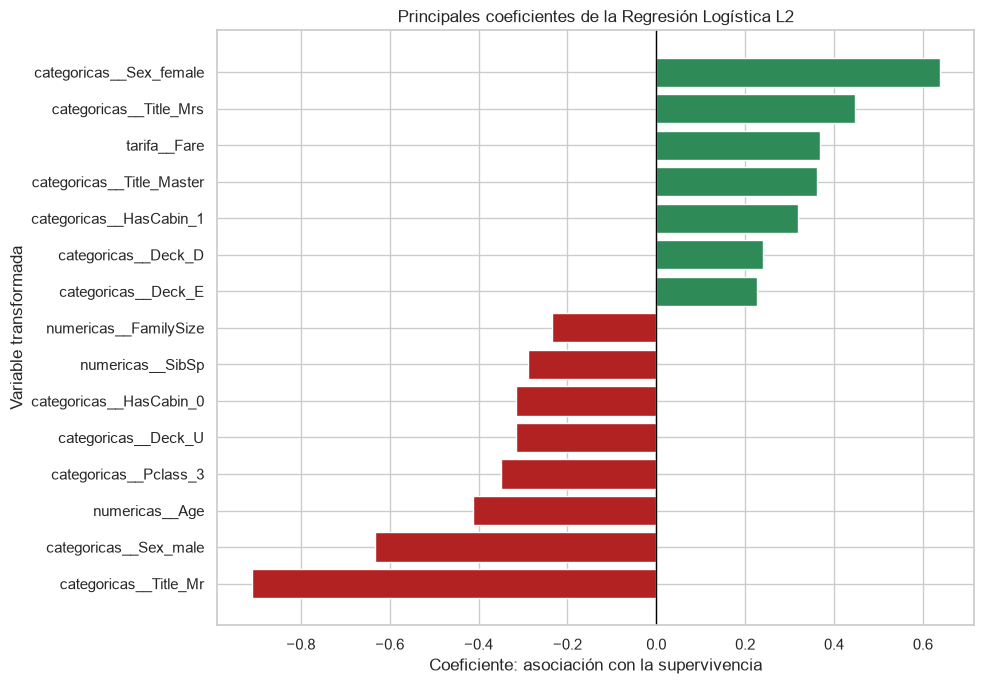

In [31]:
preprocesador_final = modelo_final.named_steps["preprocesamiento"]
clasificador_final = modelo_final.named_steps["clasificador"]
nombres_transformados = preprocesador_final.get_feature_names_out()

coeficientes_finales = pd.DataFrame({
    "variable_transformada": nombres_transformados,
    "coeficiente": clasificador_final.coef_.ravel(),
})
coeficientes_finales["magnitud_absoluta"] = coeficientes_finales["coeficiente"].abs()
coeficientes_finales["odds_ratio"] = np.exp(coeficientes_finales["coeficiente"])
coeficientes_principales = coeficientes_finales.nlargest(15, "magnitud_absoluta").sort_values("coeficiente")
display(coeficientes_principales.sort_values("magnitud_absoluta", ascending=False).round(4))

colores_coeficientes = np.where(coeficientes_principales["coeficiente"] >= 0, "seagreen", "firebrick")
plt.figure(figsize=(10, 7))
plt.barh(
    coeficientes_principales["variable_transformada"],
    coeficientes_principales["coeficiente"],
    color=colores_coeficientes,
)
plt.axvline(0, color="black", linewidth=1)
plt.title("Principales coeficientes de la Regresión Logística L2")
plt.xlabel("Coeficiente: asociación con la supervivencia")
plt.ylabel("Variable transformada")
plt.tight_layout()
plt.show()

### Lectura de las variables relevantes

La importancia por permutación identifica a **Sex** y **Title** como los predictores que más contribuyen al AUC del modelo en validación. A continuación aparecen variables relacionadas con la estructura familiar (`SibSp` y `FamilySize`), la tarifa y la clase del pasajero. Las importancias ligeramente negativas de algunas variables son pequeñas y pueden atribuirse a variación muestral o redundancia con otros predictores; no constituyen evidencia de un efecto protector o perjudicial.

Los coeficientes aportan la dirección de las asociaciones. Ser mujer, poseer títulos como `Mrs` o `Master`, pagar una tarifa mayor y disponer de información de cabina se asocian positivamente con la supervivencia estimada. En cambio, el título `Mr`, ser hombre, una mayor edad, viajar en tercera clase y un mayor número de hermanos o cónyuges se asocian negativamente. Estos patrones son compatibles con la conocida prioridad de evacuación y con diferencias socioeconómicas presentes en los datos.

Las variables numéricas fueron estandarizadas y las categóricas codificadas mediante one-hot encoding. Por ello, los coeficientes y *odds ratios* deben interpretarse dentro de este pipeline regularizado y no como efectos causales ni como cambios directos por una unidad de la variable original.

## 6.5 Alcance y limitaciones

- El conjunto de entrenamiento contiene menos de mil pasajeros, por lo que las métricas presentan variación entre particiones.
- Los datos históricos del Titanic no representan necesariamente otros contextos o poblaciones.
- La ingeniería de variables utiliza información disponible en los registros, pero atributos como título, clase y tarifa pueden reflejar factores sociales correlacionados.
- Las importancias y los coeficientes describen asociaciones predictivas, no relaciones causales.
- El umbral `0,50` se conserva para facilitar una comparación transparente; un caso de uso real debería ajustarlo según el costo de falsos positivos y falsos negativos.

### Resultado del Bloque 6

Se fija Regresión Logística L2 optimizada (`C = 0,1`) como modelo final y se mantiene el test interno sin observar. En el Bloque 7 se reentrenará esta configuración con entrenamiento más validación y se realizará una única evaluación final sobre el test reservado.

# Bloque 7. Evaluación final y predicción Kaggle

El modelo, los hiperparámetros, la métrica principal y el umbral ya fueron fijados. Primero se reentrena la Regresión Logística L2 con las muestras de entrenamiento y validación combinadas. Después se abre el **test interno una sola vez** para obtener una estimación final de generalización.

Finalmente, sin modificar la decisión tomada a partir del test, la misma configuración se ajusta con las 891 observaciones etiquetadas y se utiliza para generar el archivo de predicciones solicitado por Kaggle.

## 7.1 Reentrenamiento con los datos de desarrollo

Se combinan entrenamiento y validación, obteniendo el 85 % de los datos etiquetados. No se repite la búsqueda de hiperparámetros: se conserva exactamente `C = 0,1`, seleccionado en el Bloque 5.

In [32]:
X_desarrollo = pd.concat([X_train, X_valid], axis=0)
y_desarrollo = pd.concat([y_train, y_valid], axis=0)

assert set(X_desarrollo.index).isdisjoint(X_test.index)
assert len(X_desarrollo) + len(X_test) == len(train_df)

modelo_final_desarrollo = clone(modelo_final)
modelo_final_desarrollo.fit(X_desarrollo, y_desarrollo)

print(f"Observaciones para reentrenamiento: {len(X_desarrollo)}")
print(f"Observaciones reservadas para test interno: {len(X_test)}")
print(f"Configuración conservada: {hiperparametros_finales}")

Observaciones para reentrenamiento: 757
Observaciones reservadas para test interno: 134
Configuración conservada: {'clasificador__C': np.float64(0.1)}


## 7.2 Evaluación única sobre el test interno

Esta es la primera evaluación del modelo seleccionado sobre las 134 observaciones reservadas. Las probabilidades se utilizan para AUC y KS; las métricas de clase se calculan con el umbral previamente fijado en `0,50`.

In [33]:
probabilidad_test_final = modelo_final_desarrollo.predict_proba(X_test)[:, 1]
prediccion_test_final = (probabilidad_test_final >= UMBRAL_FINAL).astype(int)

metricas_test_final = pd.DataFrame([{
    "modelo": NOMBRE_MODELO_FINAL,
    "muestra": "Test interno",
    "Accuracy": accuracy_score(y_test, prediccion_test_final),
    "Precision": precision_score(y_test, prediccion_test_final, zero_division=0),
    "Recall": recall_score(y_test, prediccion_test_final, zero_division=0),
    "F1": f1_score(y_test, prediccion_test_final, zero_division=0),
    "AUC": roc_auc_score(y_test, probabilidad_test_final),
    "KS": calcular_ks(y_test, probabilidad_test_final),
}]).set_index("modelo")

display(metricas_test_final.round(4))
assert np.isfinite(probabilidad_test_final).all()
assert set(np.unique(prediccion_test_final)).issubset({0, 1})

,muestra,Accuracy,Precision,Recall,F1,AUC,KS
modelo,,,,,,,
Logística L2 (Ridge),Test interno,0.7612,0.6939,0.6667,0.68,0.8169,0.5627


,Validación,Test interno,diferencia_test_menos_validación
Accuracy,0.8657,0.7612,-0.1045
Precision,0.8269,0.6939,-0.1330
Recall,0.8269,0.6667,-0.1603
F1,0.8269,0.6800,-0.1469
AUC,0.9170,0.8169,-0.1001
KS,0.7819,0.5627,-0.2192


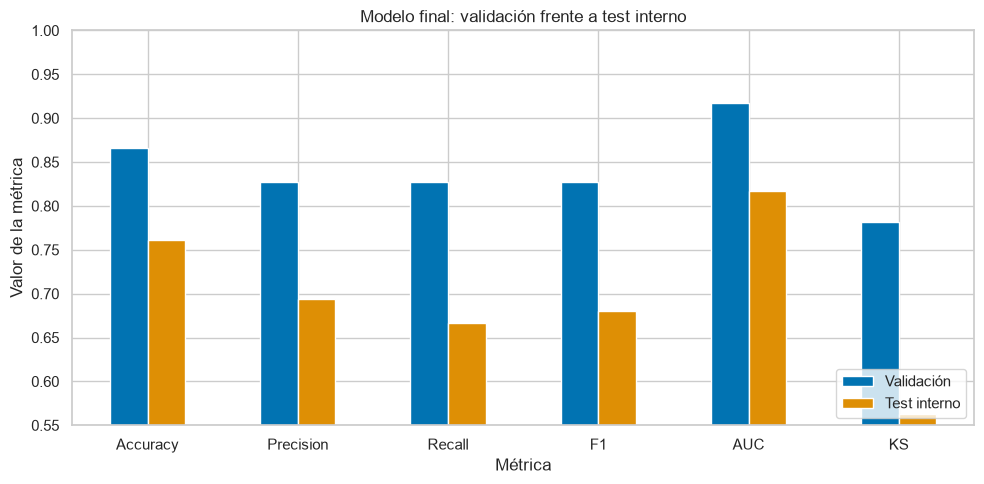

In [34]:
fila_validacion_final = metricas_optimizadas.loc[NOMBRE_MODELO_FINAL, [
    "Accuracy", "Precision", "Recall", "F1", "AUC", "KS"
]]
fila_test_final = metricas_test_final.loc[NOMBRE_MODELO_FINAL, [
    "Accuracy", "Precision", "Recall", "F1", "AUC", "KS"
]]

comparacion_validacion_test = pd.DataFrame({
    "Validación": fila_validacion_final,
    "Test interno": fila_test_final,
})
comparacion_validacion_test["diferencia_test_menos_validación"] = (
    comparacion_validacion_test["Test interno"] - comparacion_validacion_test["Validación"]
)
display(comparacion_validacion_test.round(4))

comparacion_validacion_test[["Validación", "Test interno"]].plot(
    kind="bar", figsize=(10, 5), ylim=(0.55, 1.0), rot=0
)
plt.title("Modelo final: validación frente a test interno")
plt.ylabel("Valor de la métrica")
plt.xlabel("Métrica")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

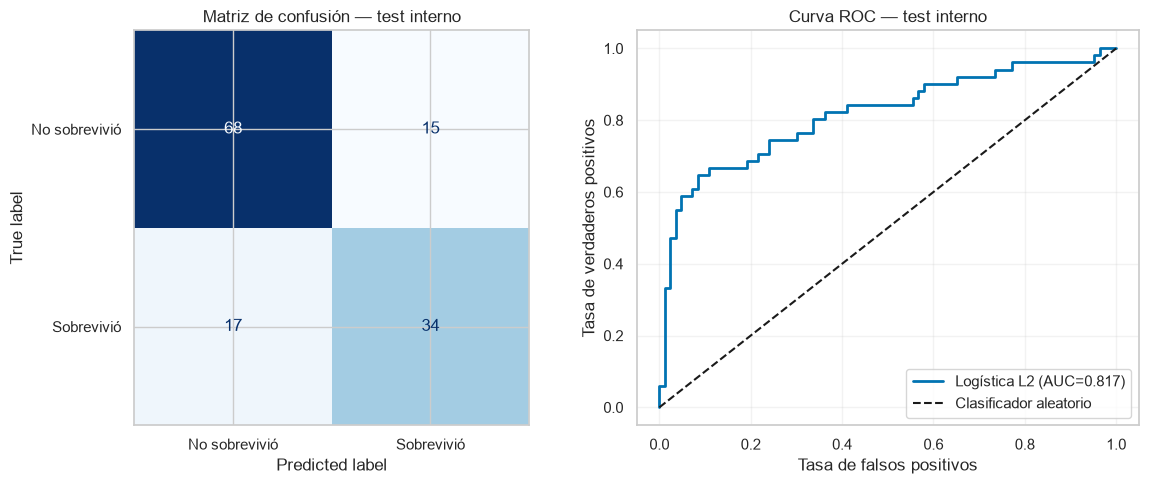

In [35]:
fig, ejes = plt.subplots(1, 2, figsize=(12, 5))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    prediccion_test_final,
    labels=[0, 1],
    display_labels=["No sobrevivió", "Sobrevivió"],
    cmap="Blues",
    colorbar=False,
    ax=ejes[0],
)
ejes[0].set_title("Matriz de confusión — test interno")

fpr_test, tpr_test, _ = roc_curve(y_test, probabilidad_test_final)
auc_test_final = roc_auc_score(y_test, probabilidad_test_final)
ejes[1].plot(fpr_test, tpr_test, linewidth=2, label=f"Logística L2 (AUC={auc_test_final:.3f})")
ejes[1].plot([0, 1], [0, 1], "k--", label="Clasificador aleatorio")
ejes[1].set_title("Curva ROC — test interno")
ejes[1].set_xlabel("Tasa de falsos positivos")
ejes[1].set_ylabel("Tasa de verdaderos positivos")
ejes[1].legend(loc="lower right")
ejes[1].grid(alpha=0.25)

plt.tight_layout()
plt.show()

## 7.3 Entrenamiento completo y archivo para Kaggle

Una vez registrada la evaluación final, se reentrena la configuración seleccionada con las 891 observaciones etiquetadas. El archivo generado conserva `PassengerId` y agrega la predicción binaria `Survived`, siguiendo exactamente el formato requerido por Kaggle.

In [36]:
X_total_etiquetado = crear_variables(train_df.drop(columns="Survived"))
y_total_etiquetado = train_df["Survived"].astype(int)

modelo_final_kaggle = clone(modelo_final)
modelo_final_kaggle.fit(X_total_etiquetado, y_total_etiquetado)
probabilidad_kaggle = modelo_final_kaggle.predict_proba(X_kaggle)[:, 1]
prediccion_kaggle = (probabilidad_kaggle >= UMBRAL_FINAL).astype(int)

submission_unidad2 = pd.DataFrame({
    "PassengerId": kaggle_test_df["PassengerId"].astype(int),
    "Survived": prediccion_kaggle,
})
ruta_submission = OUTPUT_DIR / "titanic_submission_unidad2.csv"
submission_unidad2.to_csv(ruta_submission, index=False)

assert submission_unidad2.shape == (418, 2)
assert submission_unidad2.columns.tolist() == ["PassengerId", "Survived"]
assert submission_unidad2["PassengerId"].equals(kaggle_test_df["PassengerId"].astype(int))
assert set(submission_unidad2["Survived"].unique()).issubset({0, 1})

print(f"Archivo guardado en: {ruta_submission}")
print(f"Predicciones de supervivencia: {submission_unidad2['Survived'].sum()} de {len(submission_unidad2)}")
display(submission_unidad2.head())

Archivo guardado en: C:\Users\cesar\Documents\Codex\Proyecto\trabajo_machine_learning_titanic\outputs\titanic_submission_unidad2.csv
Predicciones de supervivencia: 160 de 418


,PassengerId,Survived
0,892,0
1,893,0
2,894,0
3,895,0
4,896,1


In [37]:
import joblib

ruta_modelo = OUTPUT_DIR / "modelo_final_logistica_l2_unidad2.joblib"
joblib.dump(modelo_final_kaggle, ruta_modelo)

print(f"Pipeline final guardado en: {ruta_modelo}")
print(f"Tamaño del archivo: {ruta_modelo.stat().st_size / 1024:.1f} KB")

Pipeline final guardado en: C:\Users\cesar\Documents\Codex\Proyecto\trabajo_machine_learning_titanic\outputs\modelo_final_logistica_l2_unidad2.joblib
Tamaño del archivo: 6.7 KB


## 7.4 Interpretación de la evaluación final

En el test interno, la Regresión Logística L2 obtuvo **AUC = 0,8169**, **accuracy = 0,7612**, **F1 = 0,6800** y **KS = 0,5627**. La matriz de confusión contiene 68 verdaderos negativos, 15 falsos positivos, 17 falsos negativos y 34 verdaderos positivos. Por lo tanto, el modelo clasificó correctamente 102 de los 134 pasajeros reservados.

El AUC disminuyó `0,1001` respecto de la validación externa y F1 disminuyó `0,1469`. Esta diferencia indica que la partición de validación fue optimista y confirma la variabilidad esperable en un conjunto pequeño. Sin embargo, un AUC superior a `0,80` conserva una capacidad de discriminación claramente mayor que la de un clasificador aleatorio. El resultado final debe comunicarse sin reemplazar el modelo ni reajustar hiperparámetros, ya que hacerlo después de observar el test produciría fuga de información.

La diferencia entre validación y test también muestra por qué no debe evaluarse un proyecto únicamente con la mejor cifra obtenida durante el desarrollo. La validación cruzada, la partición independiente y el reporte de brechas entregan una evaluación más realista de la incertidumbre.

### Resultado del Bloque 7

El experimento predictivo quedó cerrado con una evaluación única y reproducible sobre el test interno. Luego se entrenó la misma Regresión Logística L2 con todos los datos etiquetados y se generó `outputs/titanic_submission_unidad2.csv`, con 418 filas y las columnas requeridas por Kaggle. El pipeline completo también quedó guardado en `outputs/modelo_final_logistica_l2_unidad2.joblib`.

El archivo Kaggle contiene 160 predicciones de supervivencia. Como `test.csv` no incluye la variable real `Survived`, su rendimiento solo puede conocerse al enviar el archivo a la plataforma. En el siguiente bloque se consolidarán las conclusiones, la reproducibilidad y los entregables del trabajo.

# Bloque 8. Conclusiones, reproducibilidad y entregables

Este bloque consolida los resultados de la Unidad 2 y verifica que los productos necesarios puedan reproducirse desde los datos originales.

## 8.1 Cumplimiento de los objetivos

| Objetivo | Evidencia desarrollada | Estado |
|---|---|---|
| Continuar el pipeline de la Unidad 1 | Misma ingeniería de variables, partición estratificada y `ColumnTransformer` | Cumplido |
| Entrenar algoritmos penalizados | Regresión logística L1, L2 y Elastic Net | Cumplido |
| Entrenar Random Forest, XGBoost y una red neuronal | Modelos implementados dentro de pipelines comparables | Cumplido |
| Calcular métricas de éxito | Accuracy, Precision, Recall, F1, AUC y KS en entrenamiento y validación | Cumplido |
| Optimizar hiperparámetros | Grid Search y Randomized Search con validación cruzada estratificada | Cumplido |
| Interpretar y seleccionar el modelo | Comparación de generalización, importancia por permutación y coeficientes | Cumplido |
| Evaluar una sola vez en test | Evaluación final de Regresión Logística L2 sobre 134 observaciones reservadas | Cumplido |
| Generar predicciones nuevas | Archivo de 418 predicciones con formato Kaggle | Cumplido |

## 8.2 Resumen consolidado del modelo final

La tabla reúne las evaluaciones relevantes de Regresión Logística L2. El AUC de validación cruzada es un promedio de cinco folds del entrenamiento; las filas de validación y test corresponden a particiones independientes.

In [38]:
fila_busqueda_final = resumen_busquedas.set_index("modelo").loc[NOMBRE_MODELO_FINAL]
resumen_modelo_final = pd.DataFrame([
    {
        "etapa": "Validación cruzada estratificada",
        "observaciones": len(X_train),
        "Accuracy": np.nan, "Precision": np.nan, "Recall": np.nan,
        "F1": np.nan, "AUC": fila_busqueda_final["AUC_CV"], "KS": np.nan,
    },
    {
        "etapa": "Validación externa",
        "observaciones": len(X_valid),
        **metricas_optimizadas.loc[NOMBRE_MODELO_FINAL, [
            "Accuracy", "Precision", "Recall", "F1", "AUC", "KS"
        ]].to_dict(),
    },
    {
        "etapa": "Test interno final",
        "observaciones": len(X_test),
        **metricas_test_final.loc[NOMBRE_MODELO_FINAL, [
            "Accuracy", "Precision", "Recall", "F1", "AUC", "KS"
        ]].to_dict(),
    },
])
display(resumen_modelo_final.round(4))

ruta_resumen = OUTPUT_DIR / "resumen_resultados_unidad2.csv"
resumen_modelo_final.to_csv(ruta_resumen, index=False)
print(f"Resumen exportado en: {ruta_resumen}")

,etapa,observaciones,Accuracy,Precision,Recall,F1,AUC,KS
0,Validación cruzada estratificada,623,NaN,NaN,NaN,NaN,0.8716,NaN
1,Validación externa,134,0.8657,0.8269,0.8269,0.8269,0.9170,0.7819
2,Test interno final,134,0.7612,0.6939,0.6667,0.6800,0.8169,0.5627


Resumen exportado en: C:\Users\cesar\Documents\Codex\Proyecto\trabajo_machine_learning_titanic\outputs\resumen_resultados_unidad2.csv


## 8.3 Conclusiones generales

1. Los modelos lineales regularizados entregaron el mejor equilibrio inicial. L1, L2 y Elastic Net superaron un AUC de `0,92` en la partición de validación base, mostrando que la ingeniería de variables permitió representar relaciones predictivas relevantes sin exigir una arquitectura compleja.
2. Los modelos de árboles fueron más sensibles al sobreajuste. Random Forest alcanzó un AUC de entrenamiento cercano a uno, pero cayó a `0,8540` en validación. La optimización redujo su complejidad y elevó su AUC externo hasta `0,9088`, demostrando la utilidad práctica de ajustar hiperparámetros.
3. XGBoost obtuvo el mayor AUC promedio durante la validación cruzada (`0,8808`), aunque con una brecha de generalización mayor. Regresión Logística L2 fue seleccionada porque combinó una brecha pequeña, el mayor AUC entre los candidatos optimizados en validación externa y una interpretación más transparente.
4. En el test interno final, el modelo alcanzó AUC `0,8169`, accuracy `0,7612` y F1 `0,6800`. La caída respecto de validación evidencia que una sola partición puede entregar una visión optimista y que la incertidumbre debe formar parte del reporte.
5. `Sex` y `Title` fueron los predictores más importantes, seguidos por variables familiares, tarifa y clase. Estos resultados describen asociaciones históricas presentes en el conjunto Titanic y no deben interpretarse como relaciones causales.
6. El uso integrado de ingeniería de variables, pipelines, validación cruzada, optimización y test reservado permitió construir un proceso completo, trazable y sin fuga deliberada de información.

## 8.4 Reproducibilidad

Para reproducir el trabajo se debe instalar `requirements.txt` y ejecutar todas las celdas en orden desde la raíz del proyecto o desde la carpeta `notebooks`. Las rutas se detectan automáticamente. Los CSV originales nunca se sobrescriben y todos los productos se guardan en `outputs`.

In [39]:
import matplotlib
import joblib

versiones_entorno = pd.DataFrame({
    "componente": [
        "Python", "pandas", "NumPy", "matplotlib",
        "seaborn", "scikit-learn", "XGBoost", "joblib",
    ],
    "versión": [
        platform.python_version(), pd.__version__, np.__version__, matplotlib.__version__,
        sns.__version__, sklearn.__version__, xgboost.__version__, joblib.__version__,
    ],
})
display(versiones_entorno)

archivos_requeridos = [
    DATA_DIR / "train.csv",
    DATA_DIR / "test.csv",
    PROJECT_DIR / "requirements.txt",
    PROJECT_DIR / "notebooks" / "trabajo_titanic_unidad2.ipynb",
    ruta_submission,
    ruta_modelo,
    ruta_resumen,
]
verificacion_archivos = pd.DataFrame({
    "archivo": [str(ruta.relative_to(PROJECT_DIR)) for ruta in archivos_requeridos],
    "existe": [ruta.exists() for ruta in archivos_requeridos],
    "tamaño_KB": [round(ruta.stat().st_size / 1024, 1) if ruta.exists() else np.nan for ruta in archivos_requeridos],
})
display(verificacion_archivos)
assert verificacion_archivos["existe"].all()

,componente,versión
0,Python,3.12.14
1,pandas,3.0.5
2,NumPy,2.5.2
3,matplotlib,3.11.1
4,seaborn,0.13.2
5,scikit-learn,1.9.0
6,XGBoost,3.4.1
7,joblib,1.5.3


,archivo,existe,tamaño_KB
0,data\train.csv,True,59.8
1,data\test.csv,True,28.0
2,requirements.txt,True,0.1
3,notebooks\trabajo_titanic_unidad2.ipynb,True,763.4
4,outputs\titanic_submission_unidad2.csv,True,3.2
5,outputs\modelo_final_logistica_l2_unidad2.joblib,True,6.7
6,outputs\resumen_resultados_unidad2.csv,True,0.4


## 8.5 Entregables preparados

- `notebooks/trabajo_titanic_unidad2.ipynb`: desarrollo completo, ejecutado y documentado.
- `outputs/titanic_submission_unidad2.csv`: predicciones para los 418 registros de Kaggle.
- `outputs/modelo_final_logistica_l2_unidad2.joblib`: pipeline final entrenado con todos los datos etiquetados.
- `outputs/resumen_resultados_unidad2.csv`: consolidación de métricas del modelo seleccionado.
- `requirements.txt`: dependencias necesarias para reproducir el análisis.
- `README.md`: descripción, estructura y forma de ejecución del proyecto.

## Referencias

- Universidad Mayor. *Machine Learning — Contenido de la Unidad 2* (`mle_ce_u2.pdf`).
- Universidad Mayor. *Actividad Unidad 2* (`actividad.pdf`).
- IBM. [¿Qué es Random Forest?](https://www.ibm.com/mx-es/think/topics/random-forest).
- Kaggle. [Titanic — Machine Learning from Disaster](https://www.kaggle.com/competitions/titanic).
- Scikit-learn. [User Guide](https://scikit-learn.org/stable/user_guide.html).
- XGBoost. [Python API Reference](https://xgboost.readthedocs.io/en/stable/python/python_api.html).
- Material audiovisual complementario proporcionado para la actividad: [video 1](https://youtu.be/XP66zYVfZyc), [video 2](https://www.youtube.com/watch?v=MbUpzvLc5y4) y [video 3](https://www.youtube.com/watch?v=yKUk5FBmcwo).

# Cierre

El trabajo de la Unidad 2 queda finalizado con un pipeline reproducible, seis modelos base, optimización de cuatro candidatos, selección justificada de Regresión Logística L2, evaluación sobre un test reservado y generación de predicciones para nuevos datos. Los resultados muestran tanto el valor predictivo del modelo como sus límites de generalización, manteniendo una separación clara entre desarrollo y evaluación final.